# Lab 8 — Frequency Domain Filtering
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers:
1. The example from the lab manual — **Laplacian filtering in the frequency domain**
2. The assessment task — **Sobel filtering in the frequency domain**

> instead of filtering pixels in space (Labs 5 & 7), we now filter in **frequency space** using the Fourier Transform.

## Setup — Import libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

%matplotlib inline

---
## Theory — What is the Frequency Domain?

Up to now (Labs 5 & 7) we filtered by **convolution in the spatial domain** — sliding a kernel over pixels. The **frequency domain** is a different way of thinking about the same image.

### Every image is a sum of waves
The **Fourier Transform** says any image can be written as a sum of sine waves of different frequencies, orientations, and amplitudes.
- **Low frequencies** → slow variations → smooth regions, overall brightness.
- **High frequencies** → fast variations → edges, fine texture, noise.

### Why bother?
Because filtering in the frequency domain is **very intuitive**:
- Want to blur the image? → **kill the high frequencies**.
- Want to sharpen it? → **boost the high frequencies**.
- Want to find edges? → **keep only the high frequencies**.

### The magic identity
Mathematically, convolution in space = **multiplication** in frequency:

$$f(x,y) * h(x,y) \;\longleftrightarrow\; F(u,v) \cdot H(u,v)$$

So instead of convolving a kernel with the image, we:
1. Take the FFT of the image → `F`
2. Multiply by a filter `H`
3. Take the inverse FFT to get the filtered image back

### Key functions in `numpy.fft`

| Function | Purpose |
|---|---|
| `fft2(image)` | 2D Fast Fourier Transform |
| `ifft2(F)` | Inverse 2D FFT (back to image) |
| `fftshift(F)` | Moves zero-frequency to the center (for viewing) |
| `ifftshift(H)` | Moves zero-frequency back to the top-left corner |
| `fftfreq(N)` | Generates frequency values for an N-point FFT |

### Two things to remember
1. **FFT output is complex** (has real and imaginary parts). For filtering we multiply; for display we use `np.abs()` or `.real`.
2. **FFT is centered at the corner (0,0), not the middle.** Use `fftshift` to move the center to the middle for **display**, but use raw FFT order for **computation** (or remember to `ifftshift` afterwards).


## Task 1 — Laplacian in the Frequency Domain (from the lab manual)

In the **spatial domain**, the Laplacian is a 3×3 kernel:

$$\begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

In the **frequency domain**, the exact same Laplacian operator has a beautiful closed-form expression:

$$H(u,v) = -4\pi^2(u^2 + v^2)$$

**Why does this work?** The Laplacian is the second derivative, and the Fourier transform of a derivative is multiplication by frequency. Take two derivatives → multiply by frequency squared → `-4π²(u² + v²)`.

**What it does:** The filter is **zero at the center** (no response to flat regions — DC component) and grows larger at high frequencies (big response to edges and fine detail). It's a textbook **high-pass filter**.

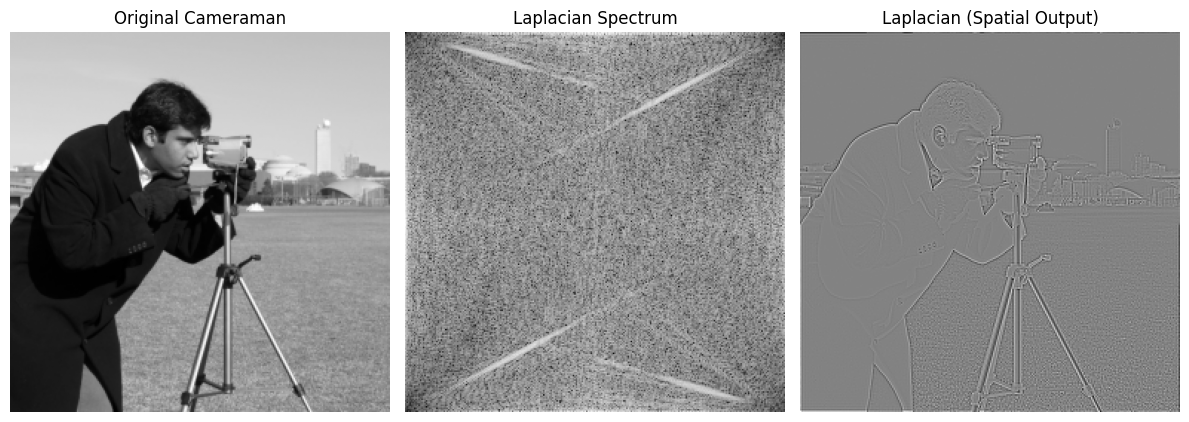

In [8]:
# --- Code from the lab manual ---
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))   # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)   # column vector of frequencies for rows
v = np.fft.fftfreq(N).reshape(1, -1)   # row vector of frequencies for columns

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain (pointwise multiplication)
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)'); plt.axis('off')

plt.tight_layout(); plt.show()

### Understanding the output
- The **Laplacian spectrum** (middle image) shows the FFT magnitude after filtering. You can see the corners are bright — that's where the high frequencies live in the un-shifted FFT. The center is dark — low frequencies were killed because the filter is zero there.
- The **spatial output** (right image) shows what the filter returned in the image domain. It looks like an **edge map** — flat regions are gray (≈ 0) and edges stand out.

---
## Assessment Task — Sobel Filter in the Frequency Domain

Sobel filters detect edges — one kernel for horizontal edges (`sobel_x`), one for vertical edges (`sobel_y`). In the spatial domain these are 3×3 kernels:

$$\text{Sobel}_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \quad \text{Sobel}_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

### Why this task is trickier than Task 1
For the Laplacian, we had a clean closed-form formula `−4π²(u² + v²)` that worked directly on the frequency grid. For Sobel, we only have 3×3 kernels. To use them in the frequency domain, we must:

1. **Pad** each 3×3 kernel to the image's size (e.g., 256×256) by placing it in the **center** of a zero-filled array.
2. Apply `ifftshift` to move the kernel's center from the image center to pixel (0, 0) — the convention FFT expects.
3. FFT the padded kernel to get its frequency response.
4. Multiply with the image's FFT.
5. Inverse FFT to get the result.

The helper function `center_embed_kernel` (provided in the lab) does steps 1–3 for us.

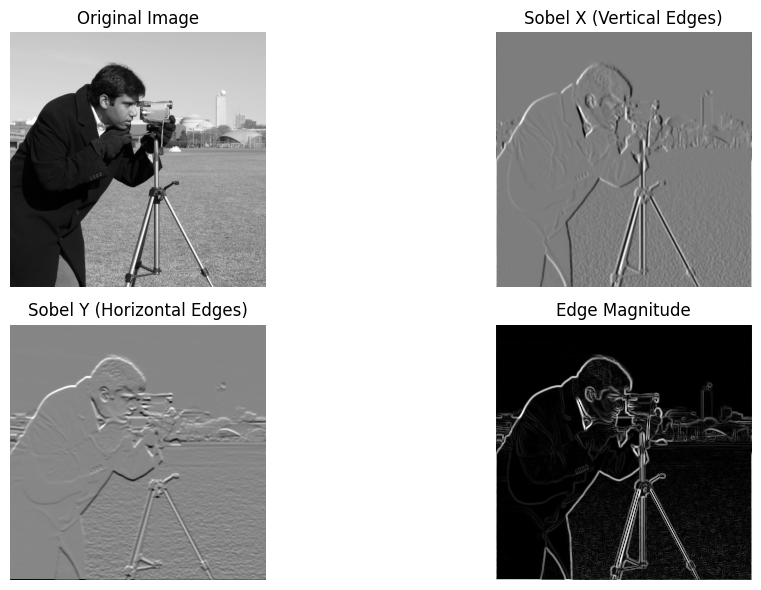

In [9]:

def center_embed_kernel(kernel, shape):
    H = np.zeros(shape)
    kh, kw = kernel.shape
    M, N = shape
    H[M//2 - kh//2 : M//2 + kh//2 + 1,
      N//2 - kw//2 : N//2 + kw//2 + 1] = kernel
    H = ifftshift(H)
    return fft2(H)



# Load image
image = data.camera()
image = resize(image, (256, 256))
M, N = image.shape

# Sobel kernels
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# FFT of image
F = fft2(image)

# Convert kernels to frequency domain
H_sobel_x = center_embed_kernel(sobel_x, (M, N))
H_sobel_y = center_embed_kernel(sobel_y, (M, N))

# Apply filters
Gx = F * H_sobel_x
Gy = F * H_sobel_y

# Inverse FFT
sobel_x_img = np.real(ifft2(Gx))
sobel_y_img = np.real(ifft2(Gy))

# Gradient magnitude
magnitude = np.sqrt(sobel_x_img**2 + sobel_y_img**2)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_x_img, cmap='gray')
plt.title('Sobel X (Vertical Edges)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sobel_y_img, cmap='gray')
plt.title('Sobel Y (Horizontal Edges)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(magnitude, cmap='gray')
plt.title('Edge Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

### Understanding the output
- **Sobel X** highlights *vertical edges* (columns where brightness changes left-to-right) — look at the camera tripod and the cameraman's coat outline.
- **Sobel Y** highlights *horizontal edges* (rows where brightness changes top-to-bottom) — the horizon line pops.
- **Magnitude** combines both to give a single edge strength per pixel — this is equivalent to what `cv2.Sobel` would give in the spatial domain.

---
## Summary Table

| Filter | What it does | How it's built in frequency domain |
|---|---|---|
| **Laplacian** (high-pass) | Edge detection, sharpening | `H = −4π²(u² + v²)` |
| **Sobel** (high-pass) | Directional edge detection | Pad 3×3 kernel, `ifftshift`, FFT |
| **Ideal Low-Pass** | Hard blur (causes ringing) | `H = 1 if D ≤ D0 else 0` |
| **Gaussian Low-Pass** | Smooth blur (no ringing) | `H = exp(−D² / 2D0²)` |
| **Gaussian High-Pass** | Edge enhancement | `H = 1 − Gaussian LP` |

## The general recipe for any frequency-domain filter

```python
# 1. Load image
image = data.camera()

# 2. Compute FFT
F = fft2(image)

# 3. Design filter H in frequency space (same shape as image)
H = ...  # Laplacian, Gaussian LP, Sobel, etc.

# 4. Multiply (not convolve!)
G = F * H

# 5. Inverse FFT to get filtered image
filtered = np.real(ifft2(G))
```

**Remember:**
- Keep FFTs in their natural un-shifted order for **computation**.
- Only `fftshift` for **display**, then `ifftshift` before filtering if needed.
- Ignore the imaginary part with `.real` or `np.real()` after `ifft2` — it should be numerically near zero for real-valued filters.

**End of notebook.**